<a href="https://colab.research.google.com/github/ZahranAzariaAnvaya/BigData26_A_2411531005_ZahranAzariaAnvaya/blob/main/Praktikum1/BD_A_P01_2411531005_Zahran_Azaria_Anvaya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **A. Langkah-langkah Praktikum**






### **J-1. Verifikasi Lingkungan Kerja**

Periksa spesifikasi mesin yang dipakai, seperti versi Python, versi
library, jumlah core, dan kapasitas RAM

In [1]:
import sys, platform, multiprocessing

print("Python :", sys.version.split()[0])
print("OS     :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python : 3.13.15
OS     : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [2]:
!free -h         # kapasitas dan sisa RAM
!df -h /content   # kapasitas dan sisa disk runtime
!java -version    # dibutuhkan PySpark pada langkah J-8

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       9.8Gi       3.7Mi       2.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  21% /
[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


### **J-2. Menghubungkan Google Drive & Menyiapkan Struktur Folder**

Karena mesin Colab bersifat sementara (file di /content hilang saat runtime berakhir), saya mount Google Drive dan menyiapkan dua folder, yaitu DIR_KERJA untuk berkas sementara yang cepat diakses, dan DIR_SIMPAN di Drive untuk menyimpan artefak yang harus tetap ada setelah runtime ditutup.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
DIR_KERJA  = "/content/data"                          # sementara, cepat
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"  # permanen
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['agregasi_per_jam.csv', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png', 'agregasi_per_jam.parquet', 'studi_kasus_permintaan.png', 'studi_kasus_tarif_per_menit.png', 'agregasi_per_jam_bulan_lain.csv', 'agregasi_per_jam_bulan_lain.parquet', 'distribusi_per_jam_bulan_lain.png', 'perbandingan_dua_bulan.png', 'pengukuran_kinerja_tugas.csv']


### **J-3. Menyiapkan Alat Ukur Waktu dan Memori**

Fungsi ukur() dibuat untuk membungkus fungsi apa
pun, lalu otomatis mencatat durasi eksekusi dan pertumbuhan RSS (memori fisik yang dipakai proses). Setiap hasil pengukuran ditampung dilist catatan agar mudah dibandingkan pada bagian analisis.

In [4]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []   # menyimpan hasil pengukuran untuk dibandingkan

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

### **J-4. Mengunduh Dataset dan Inspeksi Awal**

**Unduh Dataset**

Dataset yang digunakan adalah NYC Yellow Taxi Trip Records bulan Januari 2023 dalam format Parquet, dari sumber resmi NYC TLC. Saya mengunduhnya lewat urllib agar prosesnya tercatat dan dapat direproduksi ulang, bukan hanya diunduh manual lewat browser.

In [5]:
import urllib.request

URL  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

Ukuran file: 45.5 MB


**Inspeksi metadata**

In [6]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris  :", f"{meta.num_rows:,}")
print("Jumlah kolom  :", meta.num_columns)
print("Row group     :", meta.num_row_groups)
print("Nama kolom    :", pq.ParquetFile(PATH).schema.names)

Jumlah baris  : 3,066,766
Jumlah kolom  : 19
Row group     : 1
Nama kolom    : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


### **J-5. Memuat Data dan Mengukur Biaya Memorinya**

**Bandingkan semua kolom vs kolom terpilih**

Bandingkan pemakaian memori saat memuat semua kolom dengan hanya kolom yang saya butuhkan, karena ingin membuktikan efek *column pruning* pada format Parquet.

In [7]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh                              # membebaskan memori sebelum percobaan kedua
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 6.47 s | RSS +494.7 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.97 s | RSS +210.1 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


Lihat detail pemakaian memori per kolom untuk melihat kolom mana yang paling boros

In [8]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2   # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


Optimasi tipe data untuk menghemat memori lebih jauh

In [9]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


### **J-6. Pemeriksaan Kualitas Data dan Pembersihan (Veracity)**

Sebelum data ini dipakai untuk analisis, periksa dulu proporsi baris yang tidak masuk akal, seperti jarak nol, durasi negatif, tarif minus, dan durasi yang terlalu panjang.

**Inspeksi anomali**

In [10]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"      : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"     : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0": (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


**Filter data layak (buang baris yang berada di luar batas wajar di atas)**

In [11]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


### **J-7. Memproses File Lebih Besar dari Memori dengan Chunking**

Simulasikan kondisi file terlalu besar untuk dimuat sekaligus : data bersih ditulis ulang sebagai CSV (yang jauh lebih besar karena berupa teks tanpa kompresi),lalu baca dan agregasi per potongan (*chunk*) tanpa pernah memuat seluruh data ke memori dalam satu waktu.

In [12]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")

[tulis CSV] 38.55 s | RSS +5.6 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [13]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 5.62 s | RSS +19.8 MB
2,986,911 baris | rata-rata total_amount = 27.33


### **J-8. Pendekatan Terdistribusi: PySpark Local Mode**

Coba kueri yang sama menggunakan Spark, tetap di satu mesin
(*local mode*).

**Instalasi dan sesi Spark**

In [14]:
!pip install -q pyspark==3.5.1
!java -version

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [15]:
from pyspark.sql import SparkSession, functions as F
spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")                    # semua core mesin ini
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


**Baca & bersihkan data**

In [16]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp("tpep_dropoff_datetime")
         - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 7.81 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [17]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                       AS jumlah,
           ROUND(AVG(total_amount), 2)    AS rata_tarif,
           ROUND(AVG(tip_amount), 2)      AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()      # rencana eksekusi — perhatikan Exchange / HashAggregate
spark.stop()                # bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

### **J-9. Agregasi Akhir dengan Pandas dan Penyimpanan Artefak**

Hitung ringkasan per jam (jumlah perjalanan, rata-rata jarak/durasi/tarif, dan median tarif), lalu simpan tiga berkas - CSV, Parquet, dan catatan pengukuran kinerja ke folder Drive agar tidak hilang saat runtime ditutup.

In [18]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


### **J-10. Visualisasi Hasil**

Buat grafik batang untuk menunjukkan distribusi jumlah perjalanan per jam.

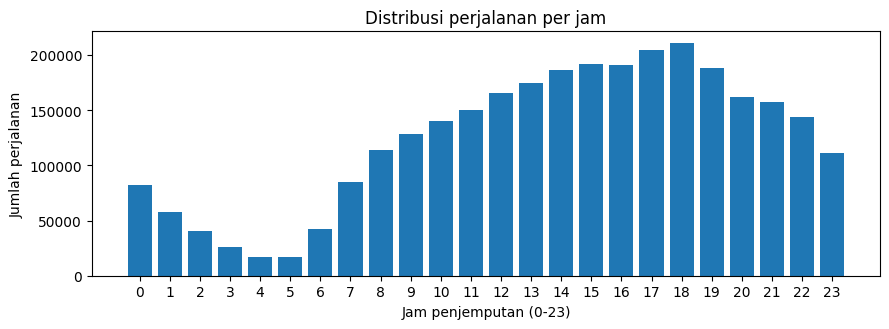

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

# **B. Tabel Analisis Hasil**

In [20]:
tabel_kinerja = pd.DataFrame(catatan)
tabel_kinerja

,langkah,detik,delta_rss_mb
0,baca semua kolom,6.47,494.7
1,baca kolom terpilih,0.97,210.1
2,tulis CSV,38.55,5.6
3,agregasi chunking,5.62,19.8
4,spark count,7.81,0.0
5,spark agregasi,6.06,0.0


# **C. Studi Kasus**

In [21]:
# Gunakan data bersih dari J-6 dan menambahkan dimensi hari.
bersih["hari"]        = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2))
ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

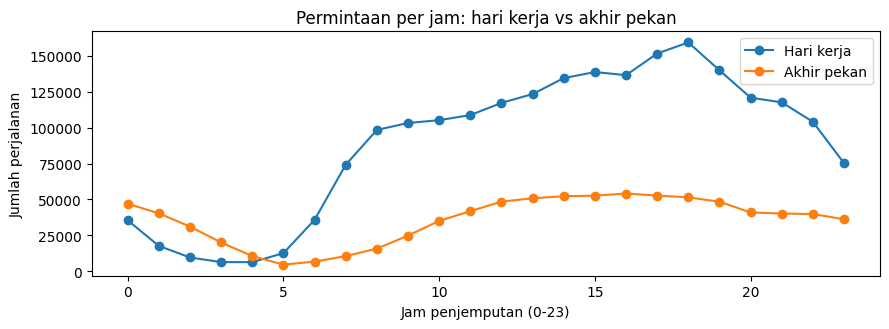

In [22]:
# Grafik 1: pola permintaan per jam, dipisah hari kerja dan akhir pekan
ringkas_reset = ringkas.reset_index()
fig, ax = plt.subplots(figsize=(9, 3.4))
for label, grp in ringkas_reset.groupby("akhir_pekan"):
    ax.plot(grp["jam"], grp["jumlah"], marker="o",
            label="Akhir pekan" if label else "Hari kerja")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Permintaan per jam: hari kerja vs akhir pekan")
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/studi_kasus_permintaan.png", dpi=150)
plt.show()

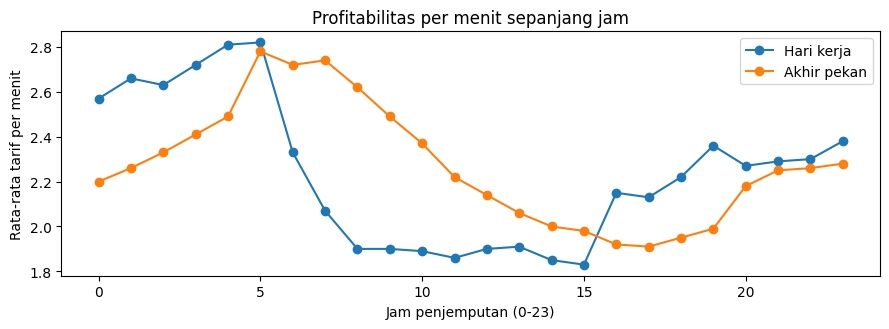

In [23]:
# Grafik 2: menjawab pertanyaan ketiga soal profitabilitas per menit di jam sibuk
fig, ax = plt.subplots(figsize=(9, 3.4))
for label, grp in ringkas_reset.groupby("akhir_pekan"):
    ax.plot(grp["jam"], grp["rata_tarif_per_menit"], marker="o",
            label="Akhir pekan" if label else "Hari kerja")
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Rata-rata tarif per menit")
ax.set_title("Profitabilitas per menit sepanjang jam")
ax.legend()
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/studi_kasus_tarif_per_menit.png", dpi=150)
plt.show()

In [24]:
# Jawaban untuk pertanyaan studi kasus

print("=== Pertanyaan 1: Jam permintaan tertinggi & terendah ===")
jam_ramai = ringkas_reset.loc[ringkas_reset["jumlah"].idxmax()]
jam_sepi  = ringkas_reset.loc[ringkas_reset["jumlah"].idxmin()]
print(f"Paling ramai: jam {int(jam_ramai['jam'])} ({'akhir pekan' if jam_ramai['akhir_pekan'] else 'hari kerja'}), {int(jam_ramai['jumlah']):,} trip")
print(f"Paling sepi : jam {int(jam_sepi['jam'])} ({'akhir pekan' if jam_sepi['akhir_pekan'] else 'hari kerja'}), {int(jam_sepi['jumlah']):,} trip")

print("\n=== Pertanyaan 3: Jam sibuk — lebih pendek & lebih untung per menit? ===")
hari_kerja = ringkas_reset[ringkas_reset["akhir_pekan"] == False].sort_values("jam")
jam_sibuk = hari_kerja.loc[hari_kerja["jumlah"].idxmax(), "jam"]
rata_durasi_keseluruhan = hari_kerja["rata_durasi"].mean()
rata_tarif_keseluruhan  = hari_kerja["rata_tarif_per_menit"].mean()
baris_sibuk = hari_kerja[hari_kerja["jam"] == jam_sibuk].iloc[0]

print(f"Jam sibuk (hari kerja): jam {int(jam_sibuk)}")
print(f"  Durasi rata-rata saat jam sibuk : {baris_sibuk['rata_durasi']} menit  (rata-rata keseluruhan: {rata_durasi_keseluruhan:.2f} menit)")
print(f"  Tarif/menit saat jam sibuk      : {baris_sibuk['rata_tarif_per_menit']}  (rata-rata keseluruhan: {rata_tarif_keseluruhan:.2f})")
print(f"  Lebih pendek dari rata-rata?    : {'Ya' if baris_sibuk['rata_durasi'] < rata_durasi_keseluruhan else 'Tidak'}")
print(f"  Lebih untung per menit?         : {'Ya' if baris_sibuk['rata_tarif_per_menit'] > rata_tarif_keseluruhan else 'Tidak'}")

=== Pertanyaan 1: Jam permintaan tertinggi & terendah ===
Paling ramai: jam 18 (hari kerja), 159,457 trip
Paling sepi : jam 5 (akhir pekan), 4,478 trip

=== Pertanyaan 3: Jam sibuk — lebih pendek & lebih untung per menit? ===
Jam sibuk (hari kerja): jam 18
  Durasi rata-rata saat jam sibuk : 14.03 menit  (rata-rata keseluruhan: 14.53 menit)
  Tarif/menit saat jam sibuk      : 2.22  (rata-rata keseluruhan: 2.24)
  Lebih pendek dari rata-rata?    : Ya
  Lebih untung per menit?         : Tidak


# **D. Latihan**

### **Latihan 1 - Lima Nilai trip_distance Terbesar**

Menampilkan lima baris dengan jarak tempuh terbesar untuk memeriksa apakah nilainya masih masuk akal.

In [25]:
lat1 = bersih.nlargest(5, "trip_distance")
lat1

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


### **Latihan 2 - Mengubah chunksize**

Ulangi J-7 dengan dua ukuran chunk berbeda (100.000 dan 1.000.000 baris) untuk membandingkan arah trade-off antara waktu proses dan pemakaian memori.

In [26]:
_, _, _ = ukur("chunking 100_000", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))
_, _, _ = ukur("chunking 1_000_000", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))
pd.DataFrame(catatan).tail(2)

[chunking 100_000] 3.71 s | RSS +34.4 MB
[chunking 1_000_000] 4.27 s | RSS +100.2 MB


,langkah,detik,delta_rss_mb
6,chunking 100_000,3.71,34.4
7,chunking 1_000_000,4.27,100.2


### **Latihan 3 - Persentase Tip per Metode Pembayaran**

Buat kolom persen_tip, tangani kasus fare_amount == 0 agar tidak terjadi pembagian dengan nol, lalu hitung rata-ratanya per payment_type.

In [27]:
lat3 = bersih.copy()
lat3["persen_tip"] = (lat3["tip_amount"] / lat3["fare_amount"].replace(0, pd.NA) * 100)
rata_tip = lat3.groupby("payment_type")["persen_tip"].mean().round(2)
rata_tip

/tmp/ipykernel_101649/2036586160.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rata_tip = lat3.groupby("payment_type")["persen_tip"].mean().round(2)


,persen_tip
payment_type,
0,20.223171
1,25.914261
2,0.002197
3,0.021737
4,0.146109


### **Latihan 4 - Kompresi Parquet: snappy vs gzip**

Simpan data bersih dengan dua jenis kompresi berbeda, lalu bandingkan ukuran berkas dan waktu penulisannya.

In [28]:
for kompresi in ["snappy", "gzip"]:
    path_out = f"{DIR_KERJA}/bersih_{kompresi}.parquet"
    ukur(f"tulis parquet {kompresi}",
         lambda kompresi=kompresi: bersih.to_parquet(path_out, index=False, compression=kompresi))
    print(kompresi, "->", round(os.path.getsize(path_out) / 1024**2, 2), "MB")

[tulis parquet snappy] 2.27 s | RSS +43.5 MB
snappy -> 58.05 MB
[tulis parquet gzip] 51.62 s | RSS -9.5 MB
gzip -> 46.55 MB


### **Latihan 5 - Konsistensi Agregasi pandas vs Spark SQL**

Buktikan bahwa hasil agregasi J-9 (pandas) dan versi Spark SQL konsisten dengan membandingkan kolom jumlah secara terprogram.

In [29]:
from pyspark.sql import SparkSession, functions as F
spark = (SparkSession.builder.appName("BD-P01-Lat5")
         .master("local[*]").config("spark.sql.shuffle.partitions", "8").getOrCreate())

sdf5 = (spark.read.parquet(PATH)
        .withColumn("durasi_menit",
                    (F.unix_timestamp("tpep_dropoff_datetime")
                     - F.unix_timestamp("tpep_pickup_datetime")) / 60)
        .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
        .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
        .filter(F.col("total_amount") > 0)
        .withColumn("jam", F.hour("tpep_pickup_datetime")))

sdf5.createOrReplaceTempView("trips_lat5")
agg_spark = spark.sql("""
    SELECT jam, COUNT(*) AS jumlah
    FROM trips_lat5
    GROUP BY jam
    ORDER BY jam
""").toPandas()

agg_pandas = agregasi[["jam", "jumlah_perjalanan"]].rename(columns={"jumlah_perjalanan": "jumlah"})
bandingkan = agg_pandas.merge(agg_spark, on="jam", suffixes=("_pandas", "_spark"))
bandingkan["selisih"] = bandingkan["jumlah_pandas"] - bandingkan["jumlah_spark"]
print("Selisih maksimum:", bandingkan["selisih"].abs().max())
spark.stop()
bandingkan

Selisih maksimum: 0


,jam,jumlah_pandas,jumlah_spark,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


In [30]:
print("Rasio kolom total vs dipakai :", meta.num_columns, "/", len(KOLOM))
print("Rasio CSV / Parquet          :", round(os.path.getsize(CSV)/os.path.getsize(PATH), 1), "x")
print("Persentase baris dibuang     :", round(100*(len(df)-len(bersih))/len(df), 2), "%")

Rasio kolom total vs dipakai : 19 / 8
Rasio CSV / Parquet          : 5.0 x
Persentase baris dibuang     : 2.6 %
